#Case Study 3: NLP
Group: Sean Feeny, Shota Muraishi

For this case study you are to perform Natural Language Processing (NLP) on a data set of interest and complete there are main objectives:

- A brief description of your data set and application
Form the most predictive model (consider at least three different models)
- Tune model parameters with cross validation and some version of grid search
- Perform topic modeling (explain how you would describe each topic and how many topics you choose)

## Description of data
The dataset provides a collection of game reviews from the Steam platform. This includes a mix of positive and negative reviews from 50 different games. We found the dataset on Kaggle

## Application
The written text in each review reveals the reviewer's opinion on a game. Since the written text is associated with a positive rating (recommended) or negative rating (not recommended), this will let us make a model to predict the overall sentiment of text written about a game.

This could hopefully then be used for any text about a particular game to predict the opinion of the writer about the game. This could perhaps be applied to social media posts, YouTube comments, or other text written about a game in order to predict the public's perception of the game.

While this dataset is specifically about game reviews, a model like this could likely also predict whether more general things are perceived positively or negatively. This is because certain words are associated with positive or negative sentiment, which will likely transfer relatively well across domains

##Getting the data and preprocessing

In [ ]:
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install pyprind
import pyprind
import os
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
import sys
import re
!pip install nltk
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving output.csv to output.csv


In [ ]:
for fn in uploaded.keys():
  # Assuming the uploaded file is a CSV, read it into a pandas DataFrame
  df = pd.read_csv(fn)


display(df.head())

,id,app_id,content,author_id,is_positive
0,181331361,100,At least its a counter strike -1/100,76561199556485100,Negative
1,180872601,100,Uh... So far my playthrough has not been great...,76561199230620391,Negative
2,177836246,100,Better mechanics than cs2,76561198417690647,Negative
3,177287444,100,buggy mess and NOT fun to play at all,76561199077268730,Negative
4,176678990,100,"Whoever came up with this, is gonna fucking ge...",76561199104544266,Negative


In [ ]:
#drop id and author_id columns
df = df.drop(['id', 'author_id'], axis=1)


In [ ]:
#count null values in each column
df.isnull().sum()

,0
app_id,0
content,428
is_positive,0


In [ ]:
#drop rows that have null values in the content column
display(df.shape)
df = df.dropna(subset=['content'])
df.isnull().sum()
display(df.shape)

(201151, 3)

(200723, 3)

In [ ]:
# Reviews should be in English, but we need to remove some reviews that slipped through the language filtering system
# Regex: match characters from non-Latin scripts
# (Cyrillic, Greek, Arabic, CJK, etc.)
non_latin_scripts = re.compile(
    r'[\u0370-\u03FF'   # Greek
    r'\u0400-\u04FF'    # Cyrillic
    r'\u0600-\u06FF'    # Arabic
    r'\u4E00-\u9FFF'    # CJK Unified Ideographs
    r'\u3040-\u30FF'    # Japanese Hiragana & Katakana
    r'\uAC00-\uD7AF]'   # Hangul (Korean)
)

def contains_non_latin_script(s: str) -> bool:
    if not isinstance(s, str):
        return False
    return bool(non_latin_scripts.search(s))

# Flag rows
df["has_non_latin_script"] = df["content"].apply(contains_non_latin_script)

# Count rows with non-Latin scripts
count_non_latin = df["has_non_latin_script"].sum()
print("Rows with non-Latin scripts:", count_non_latin)

# Remove rows containing non-Latin scripts
df_clean = df[~df["has_non_latin_script"]]
df_clean = df_clean.drop(['has_non_latin_script'], axis=1)
display(df_clean.shape)


Rows with non-Latin scripts: 3791


(196932, 3)

In [ ]:
#reset indexing
df_clean = df_clean.reset_index(drop=True)

In [ ]:
# checking for counts of a given string within the dataframe

# Define the string to match
target = "https"
count_contains = df_clean['content'].str.contains(target, na=False).sum()
print("Rows containing:", count_contains)


Rows containing: 1034


In [ ]:
#creating a preprocessing function based on the one from class
#this function keeps certain things like number ratings (8/10), emojis, emoticons
#(made with the help of AI)
def preprocess_keep_ratings_emoticons_emojis(text: str) -> str:
    """
    Preprocess text by:
    - Lowercasing
    - Keeping '/' only when between digits (e.g. 3/5)
    - Normalizing emoticons (remove noses)
    - Preserving emojis
    - Removing all other symbols
    """
    if not isinstance(text, str):
        return ""

    # Step 1: Protect ratings like 3/5 or 9/10 with alphanumeric sentinels
    ratings = re.findall(r'\d+/\d+', text)
    protected_text = text
    for i, r in enumerate(ratings):
        protected_text = protected_text.replace(r, f"ZZZRATING{i}ZZZ")

    # Step 2: Normalize emoticons (remove noses)
    emoticon_map = {
        ":-)": ":)", ":-(": ":(", ":-D": ":D", ":-P": ":P", ":-O": ":O",
    }
    for emo, simple in emoticon_map.items():
        protected_text = protected_text.replace(emo, simple)

    # Step 3: Protect simplified emoticons with alphanumeric sentinels
    emoticons = [":)", ":(", ":D", ":P", ";)", ":O"]
    for i, emo in enumerate(emoticons):
        protected_text = protected_text.replace(emo, f"ZZZEMO{i}ZZZ")

    # Step 4: Remove all non-alphanumeric except spaces and emoji ranges
    # Use \U for astral plane ranges (emoji) so Python’s re handles them correctly.
    cleaned = re.sub(
        r'[^a-zA-Z0-9 \u2600-\u26FF\u2700-\u27BF\U0001F300-\U0001F64F\U0001F900-\U0001F9FF]',
        ' ',
        protected_text
    )

    # Step 5: Restore ratings and emoticons
    for i, r in enumerate(ratings):
        cleaned = cleaned.replace(f"ZZZRATING{i}ZZZ", r)
    for i, emo in enumerate(emoticons):
        cleaned = cleaned.replace(f"ZZZEMO{i}ZZZ", emo)

    # Step 6: Normalize spaces and lowercase
    cleaned = re.sub(r'\s+', ' ', cleaned).strip().lower()

    return cleaned


In [ ]:
#applying the preprocessing function to the dataframe
df_clean['content'] = df_clean['content'].apply(preprocess_keep_ratings_emoticons_emojis)

In [ ]:
#count the rows that contain just an empty string
count_empty = (df_clean['content'] == '').sum()
print("Rows with empty content:", count_empty)
#count rows with just white space
count_whitespace = (df_clean['content'].str.isspace()).sum()
print("Rows with just white space:", count_whitespace)



Rows with empty content: 2335
Rows with just white space: 0


In [ ]:
#remove rows with empty content
df_clean = df_clean[df_clean['content'] != '']
df_clean = df_clean.reset_index(drop=True)


In [ ]:
#count the values for the is_positive column
df_clean['is_positive'].value_counts()

,count
is_positive,
Positive,99665
Negative,94932


In [ ]:
#defining the 2 tokenizers we will try with gridsearch
porter = PorterStemmer()
def tokenizer_porter(text):
     return [porter.stem(word) for word in text.split()]
def tokenizer(text):
     return text.split()

In [ ]:
nltk.download('stopwords')
#creating a custom stopword list to try by removing some words we thought were significant from the default list (no, not, nor, should, dont)
stop = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again", "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "now"]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#Predictive Models

We tried Logistic Regression, Random Forest, and Naive Bayes models. Since the dataset is large enough that computing time takes a while, we started with a small training set (test size = 0.9) and attempted a grid search on each.

The best model based on our initial grid searches was logistic regression, which was also the fastest model by far, so we went in and did a more detailed grid search with logistic regression.

In [ ]:
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)
train_df= train_df.reset_index(drop=True)
X_train = train_df['content'].values
y_train = train_df['is_positive'].values
X_test = test_df['content'].values
y_test = test_df['is_positive'].values


###Logistic regression gridsearch
After choosing logistic regression as the best model using a limited initial gridsearch with small training set, we did a series of small gridsearches with logistic regression because the runtime is somewhat long, meaning we did not try every combination of every parameter. The best parameters are shown in the code below, with the other values we tried shown in the comments


In [ ]:
#performing gridsearch with logistic regression
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        preprocessor=None)

small_param_grid = [
    {   #these are the best values we found among the ones we tried
        'vect__ngram_range': [(1, 2)],              #we tried values of (1,1), (1,2), (2,2)
        'vect__stop_words': [None],                 #we tried values of None, stopwords.words('english'), and our custome stop word list above
        'vect__tokenizer': [ tokenizer_porter],     #we tried tokenizer_porter and tokenizer
        'clf__penalty': ['l2'],                     #we tried l1 and l2
        'clf__C': [5]                               #we tried values of 0.1, 1, 10, then fine tuned it by trying values of 3,4,5,6,7,8,12,15, but 5 performed best
    }
]

lr_tfidf = Pipeline([
    ('vect', tfidf),
    ('clf', LogisticRegression(solver='liblinear'))
])

gs_lr_tfidf = GridSearchCV(lr_tfidf, small_param_grid,
                           scoring='accuracy', cv=3,
                           verbose=2, n_jobs=-1)

gs_lr_tfidf.fit(X_train, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('vect',
                                        TfidfVectorizer(lowercase=False)),
                                       ('clf',
                                        LogisticRegression(solver='liblinear'))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [5], 'clf__penalty': ['l2'],
                          'vect__ngram_range': [(1, 2)],
                          'vect__stop_words': [None],
                          'vect__tokenizer': [<function tokenizer_porter at 0x7d66ce539b20>]}],
             scoring='accuracy', verbose=2)

The best parameters and accuracy scores we got with logistic regression are shown below:

In [ ]:
print(f'Best parameter set: {gs_lr_tfidf.best_params_}')
print(f'CV Accuracy: {gs_lr_tfidf.best_score_:.3f}')
clf = gs_lr_tfidf.best_estimator_
print(f'Test Accuracy: {clf.score(X_test, y_test):.3f}')

Best parameter set: {'clf__C': 5, 'clf__penalty': 'l2', 'vect__ngram_range': (1, 2), 'vect__stop_words': None, 'vect__tokenizer': <function tokenizer_porter at 0x7d66ce539b20>}
CV Accuracy: 0.873
Test Accuracy: 0.881


###Random forest "gridsearch" (with only one option for each)
We did not end up doing a real gridsearch with random forest because it took so long. Even a false grid search with one option for each parameter as shown below took several times as long as logistic regression with gridsearch.

We tried gridsearch with the random forest model, but it did not work in a reasonable amount of time, even using the Colab GPU. Instead, we just did a false gridsearch as shown below, which performed worse than the other models.

This "grid search" got an accuracy of around 0.83


In [ ]:

# tfidf = TfidfVectorizer(strip_accents=None,
#                         lowercase=False,
#                         preprocessor=None)

# small_param_grid = [
#     {
#         'vect__ngram_range': [(1, 1)],
#         'vect__stop_words': [None],
#         'vect__tokenizer': [ tokenizer_porter],
#         'clf__n_estimators': [100]
#     }
# ]

# lr_tfidf = Pipeline([
#     ('vect', tfidf),
#     ('clf', RandomForestClassifier(random_state=1, n_jobs=-1))
# ])


# gs_lr_tfidf = GridSearchCV(lr_tfidf, small_param_grid,
#                            scoring='accuracy', cv=3,
#                            verbose=2, n_jobs=-1)

# gs_lr_tfidf.fit(X_train, y_train)

###Naive Bayes Gridsearch
We did a gridsearch with Naive bayes using the values shown in the cell below. Like the others, this initial gridsearch performed was with a small training set (test size of 0.9) due to the computing time required.

In [ ]:

# from sklearn.naive_bayes import MultinomialNB

# # TF-IDF vectorizer
# tfidf = TfidfVectorizer(strip_accents=None,
#                         lowercase=False,
#                         preprocessor=None)

# # Pipeline: TF-IDF → Naive Bayes
# nb_tfidf = Pipeline([
#     ('vect', tfidf),
#     ('clf', MultinomialNB())
# ])

# # Parameter grid
# nb_param_grid = [
#     {
#         'vect__ngram_range': [(1, 1), (1, 2)],
#         'vect__stop_words': [None],
#         'vect__tokenizer': [tokenizer_porter],
#         'vect__max_features': [None, 20000],

#         'clf__alpha': [0.1, 0.5, 1.0, 2.0]         # smoothing parameter
#     }
# ]

# # Grid search
# gs_nb_tfidf = GridSearchCV(
#     nb_tfidf,
#     nb_param_grid,
#     scoring='accuracy',
#     cv=3,
#     n_jobs=-1,
#     verbose=2
# )

# # Train model
# gs_nb_tfidf.fit(X_train, y_train)


The best results with the Naive Bayes gridsearch are shown below:

In [ ]:
#Best parameter set: {'clf__alpha': 0.5, 'vect__max_features': None, 'vect__ngram_range': (1, 2), 'vect__stop_words': None, 'vect__tokenizer': <function tokenizer_porter at 0x7ec87d628720>}
#CV Accuracy: 0.844
#Test Accuracy: 0.847

#Topic Modeling

Using the code below, we found the number of reviews for each game on the list. For topic modeling, we were hoping to be able to figure out which game a review belongs to based on the topics discussed, but since there are 50 games with different numbers of reviews, we decided to do this based just on the top 10 games with the most reviews.

In [ ]:
#count the values for the is_positive column
print(df_clean['app_id'].value_counts())
#count distinct app_id values
print("unique games: ", df_clean['app_id'].nunique())

app_id
730     23882
440     19852
570     17933
550     14940
240     11993
10      10862
620     10840
630      9766
130      9654
280      8487
300      7678
340      6900
320      6198
20       5246
30       3247
380      2949
220      2732
70       2361
400      2314
360      2052
1840     2015
1250     1653
40       1611
100      1499
420      1040
500       942
80        692
1930      674
50        609
60        508
1520      468
1900      260
1700      250
1510      248
1200      239
1280      235
1640      213
1690      178
1630      161
1300      159
1530      146
1600      138
1500      137
1313      124
1610      118
1670      114
1230       98
1002       91
1256       46
1257       45
Name: count, dtype: int64


50

The top 10 games all have over 8000 reviews, so we will use that as the cutoff:

In [ ]:
#create a new dataframe that only keeps app_id values with more than 8000 ocurrences
df_top_10 = df_clean[df_clean['app_id'].isin(df_clean['app_id'].value_counts()[df_clean['app_id'].value_counts() > 8000].index)]
df_top_10= df_top_10.reset_index(drop=True)

In [ ]:
count = CountVectorizer(stop_words='english',
...                         max_df=.1,
...                         max_features=5000)
X = count.fit_transform(df_top_10['content'].values)

In [ ]:

lda = LatentDirichletAllocation(n_components=6,
...                                 random_state=123,
...                                 learning_method='batch')
X_topics = lda.fit_transform(X)


In [ ]:
n_top_words = 10
feature_names = count.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print(f'Topic {(topic_idx)}:')
    print(' '.join([feature_names[i]
                    for i in topic.argsort()\
                    [:-n_top_words - 1:-1]]))

Topic 0:
fixtf2 bad portal don just better 10 buy need hard
Topic 1:
life half fun like 10 just original really source great
Topic 2:
bots valve fix best love bot fixtf2 unplayable yes problem
Topic 3:
shit fix dont great fucking classic tf2 com https hackers
Topic 4:
time just playing valve games people community don years played
Topic 5:
cheaters cs counter strike dead players like hate cheat cs2


In [ ]:
topic = 1
top = X_topics[:, topic].argsort()[::-1]
for iter_idx, game_idx in enumerate(top[:15]):
    print(f'\ntopic {topic} review #{(iter_idx + 1)}: (game {df_top_10['app_id'][game_idx]})')
    print(df_top_10['content'][game_idx][:300], '...')


topic 1 review #1: (game 630)
photon e1big blaser e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big e1big blaser e1big photon e1big blaser 2015coal 2015coal 2015coal 2015coal 2015coal 2015coal 2015coal 2015coal 2015coa ...

topic 1 review #2: (game 280)
even though usually i like writing long reviews this time there isn t much to say really it s just the good ol b half life b now on b half life 2 b engine the original b half life b used b goldsrc b engine which was pretty much a modified version of b quake b engine believe it or not now the game ha ...

topic 1 review #3: (game 730)
headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot headshot 

We experimented with different numbers of topics, but of the numbers we tried, the best one for categorizing the games was 6. This is partially because the top 10 games had 2 Half Life games and 3 Counter Strike games, so these groups had significant overlap, while if we picked 10 completely unrelated games, they might more likely all have their own category.

After looking at the top words in each topic, a small sample of the reviews for each topic, and the heat map below, they seem to follow a couple of patterns:

- Topic 0 seems to categorize spam or reviews that follow a set format or template, with people repeating the same phrases over and over, or in the case of the set format of reviews, copying the same review template and filling in the blanks/checking the boxes. Based on the heatmap below, this topic is somewhat uniform throughout all the games
- Topic 1 seems to be largely about Half Life games (there are 2 different half life games in this list (ids 130 and 280)) and a bit about Alien Swarm (630) and Portal 2 (620)
- Topic 2 seems to be a mostly about Team Fortress 2 (TF2, id 440)
- Topic 3 seems to have a lot of links, hence the com and https in the common word list above and the small but relatively uniform distribution of topic 3 in the heat map below
- Topic 4 seems to be about team games, with games like Dota 2 (570) and a bit of Left 4 Dead 2 (550), TF2 (440), and Alien Swarm (630)
- Topic 5 seems to be mostly about Counter Strike, with Counter Strike 2 (730) and a bit of the 2 other Counter Strike games (10 and 240)



In [ ]:
df_top_10['dominant_topic'] = np.argmax(X_topics, axis=1)
display(df_top_10.head())

,app_id,content,is_positive,dominant_topic
0,630,my friend fucking glitched out of the map dude...,Negative,1
1,630,mid,Negative,5
2,630,its just ok valve games are not usually just ok,Negative,4
3,630,nobody is playing this game,Negative,4
4,630,this game isn t very fun it runs like ass and ...,Negative,4


Heatmap of dominant topics for each app id (as a fractional amount, since the games each have different numbers of reviews):

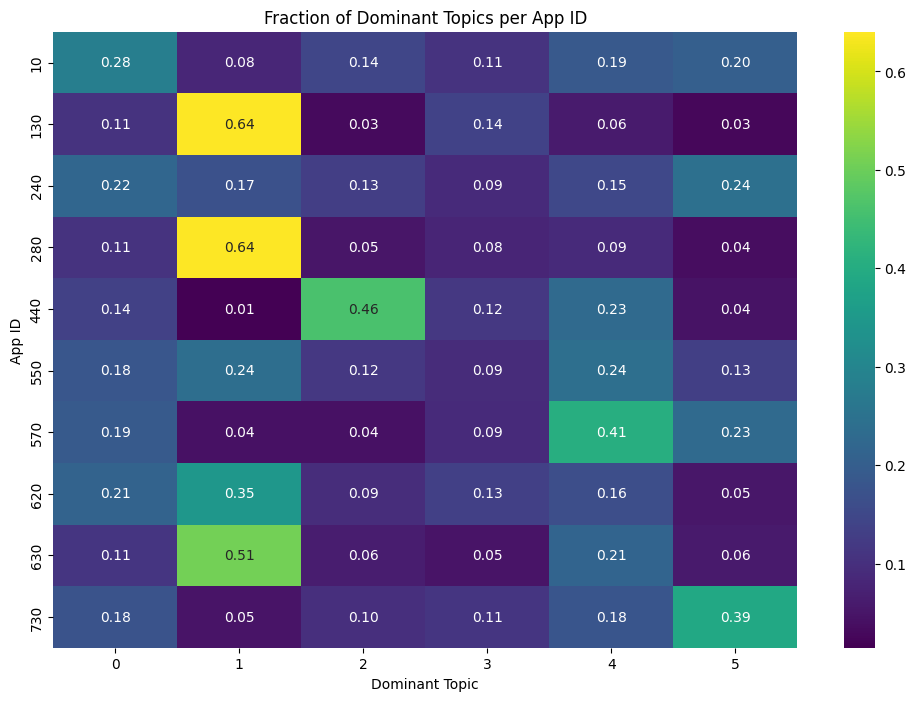

In [ ]:
# Group by app_id and dominant_topic and count occurrences
topic_app_distribution = df_top_10.groupby(['app_id', 'dominant_topic']).size().unstack(fill_value=0)

# Calculate the fraction of reviews for each app_id
topic_app_distribution_fraction = topic_app_distribution.div(topic_app_distribution.sum(axis=1), axis=0)

# Plotting the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(topic_app_distribution_fraction, cmap='viridis', annot=True, fmt='.2f')
plt.title('Fraction of Dominant Topics per App ID')
plt.xlabel('Dominant Topic')
plt.ylabel('App ID')
plt.show()

Plotting the distribution of app ids for each dominant topic (as a fractional amount, since each game has a different number of total reviews):

/tmp/ipython-input-4065978236.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=app_id_fractions.index, y=app_id_fractions.values, palette='viridis')
/tmp/ipython-input-4065978236.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=app_id_fractions.index, y=app_id_fractions.values, palette='viridis')
/tmp/ipython-input-4065978236.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=app_id_fractions.index, y=app_id_fractions.values, palette='viridis')
/tmp/ipython-input-4065978236.py:22: FutureWarning: 

Passing `palette` without as

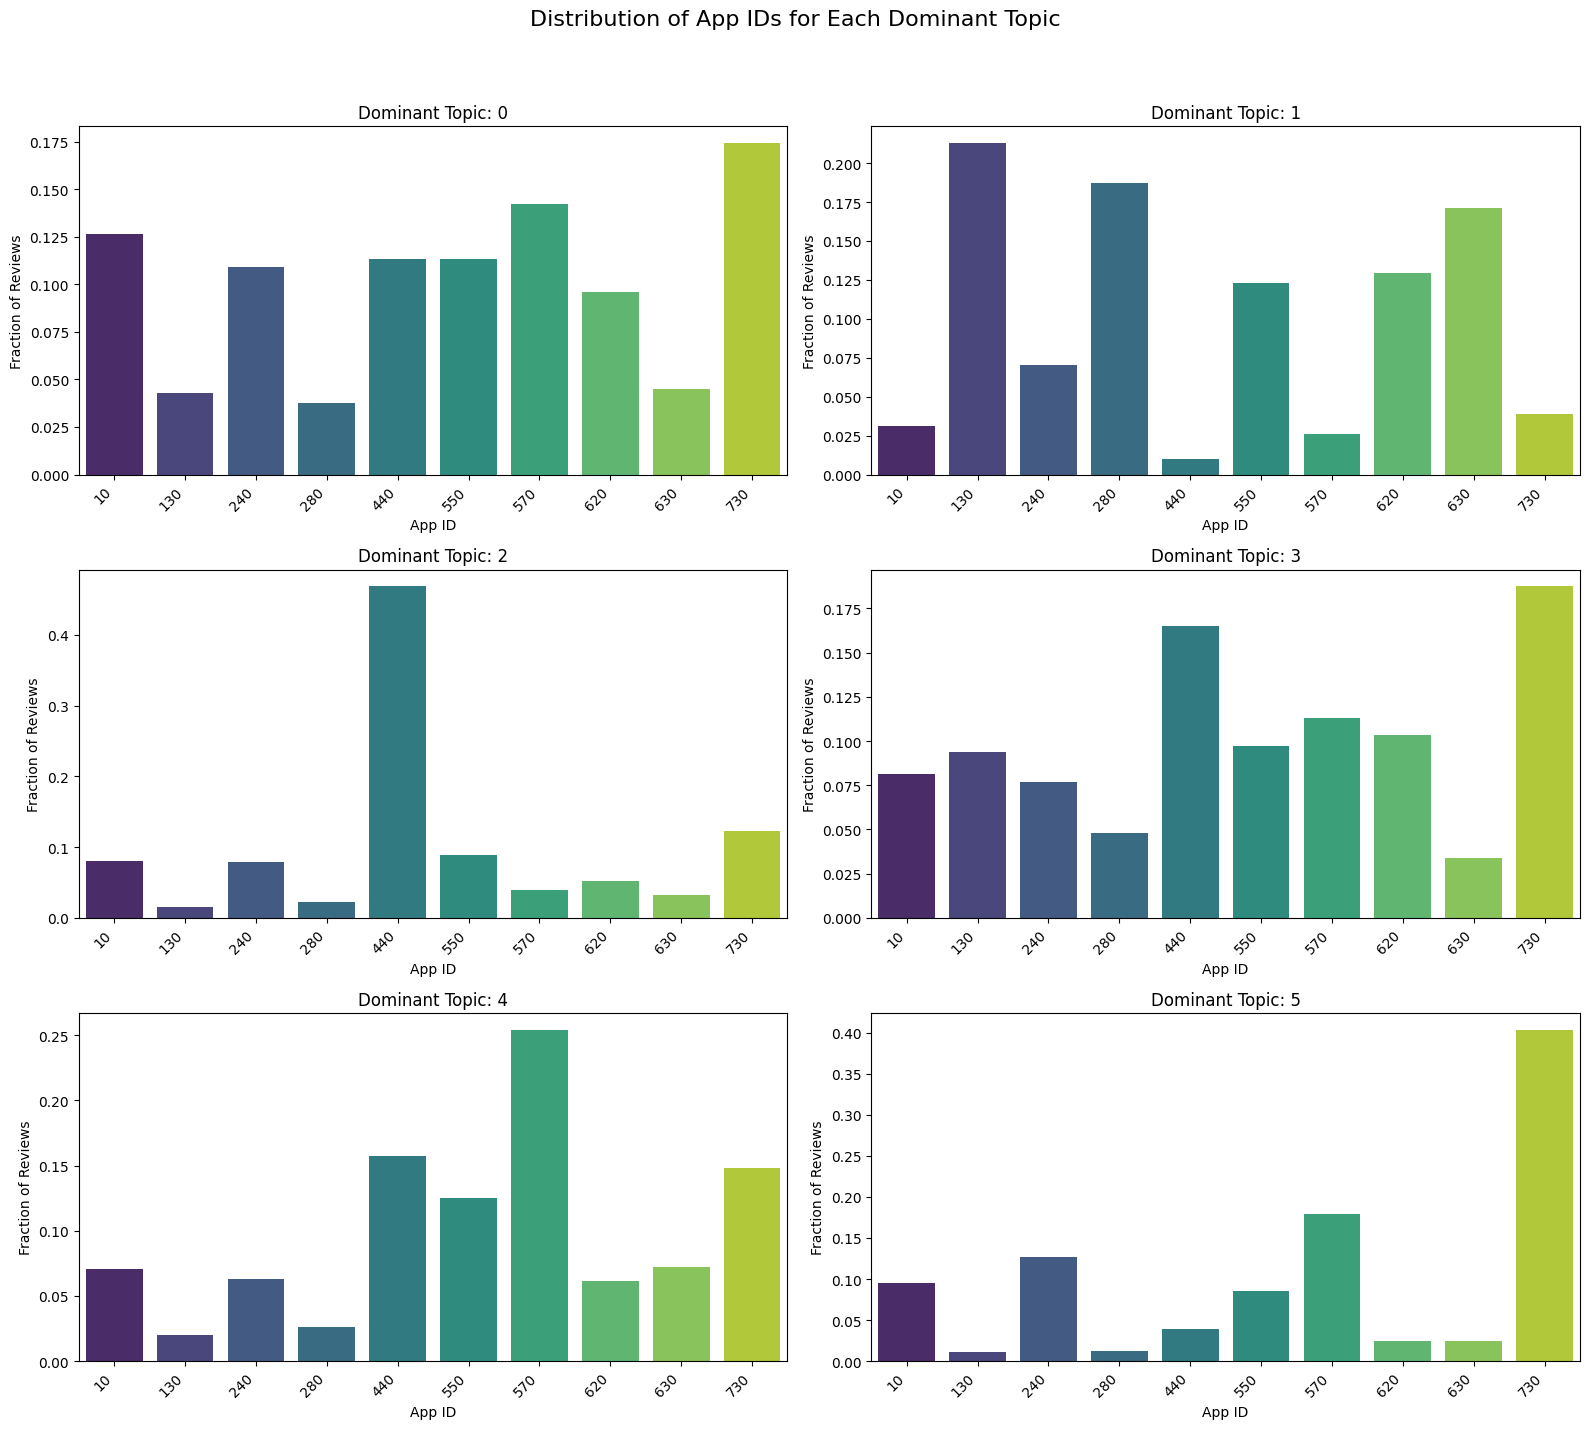

In [ ]:
unique_dominant_topics = df_top_10['dominant_topic'].unique()

# Determine grid size for the plots
num_topics = len(unique_dominant_topics)
rows = 3
cols = 2

plt.figure(figsize=(cols * 8, rows * 5))

for i, topic_val in enumerate(sorted(unique_dominant_topics)):
    plt.subplot(rows, cols, i + 1)
    # Filter data for the current dominant_topic
    df_filtered_topic = df_top_10[df_top_10['dominant_topic'] == topic_val]

    # Count the occurrences of each app_id
    app_id_counts = df_filtered_topic['app_id'].value_counts().sort_index()

    # Calculate fractions
    app_id_fractions = app_id_counts / app_id_counts.sum()

    # Create the bar plot using fractions
    sns.barplot(x=app_id_fractions.index, y=app_id_fractions.values, palette='viridis')
    plt.title(f'Dominant Topic: {topic_val}')
    plt.xlabel('App ID')
    plt.ylabel('Fraction of Reviews')
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Distribution of App IDs for Each Dominant Topic', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping titles
plt.show()

Plotting the distribution of topics for each app id:

/tmp/ipython-input-1518144921.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis')
/tmp/ipython-input-1518144921.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis')
/tmp/ipython-input-1518144921.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis')
/tmp/ipython-input-1518144921.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

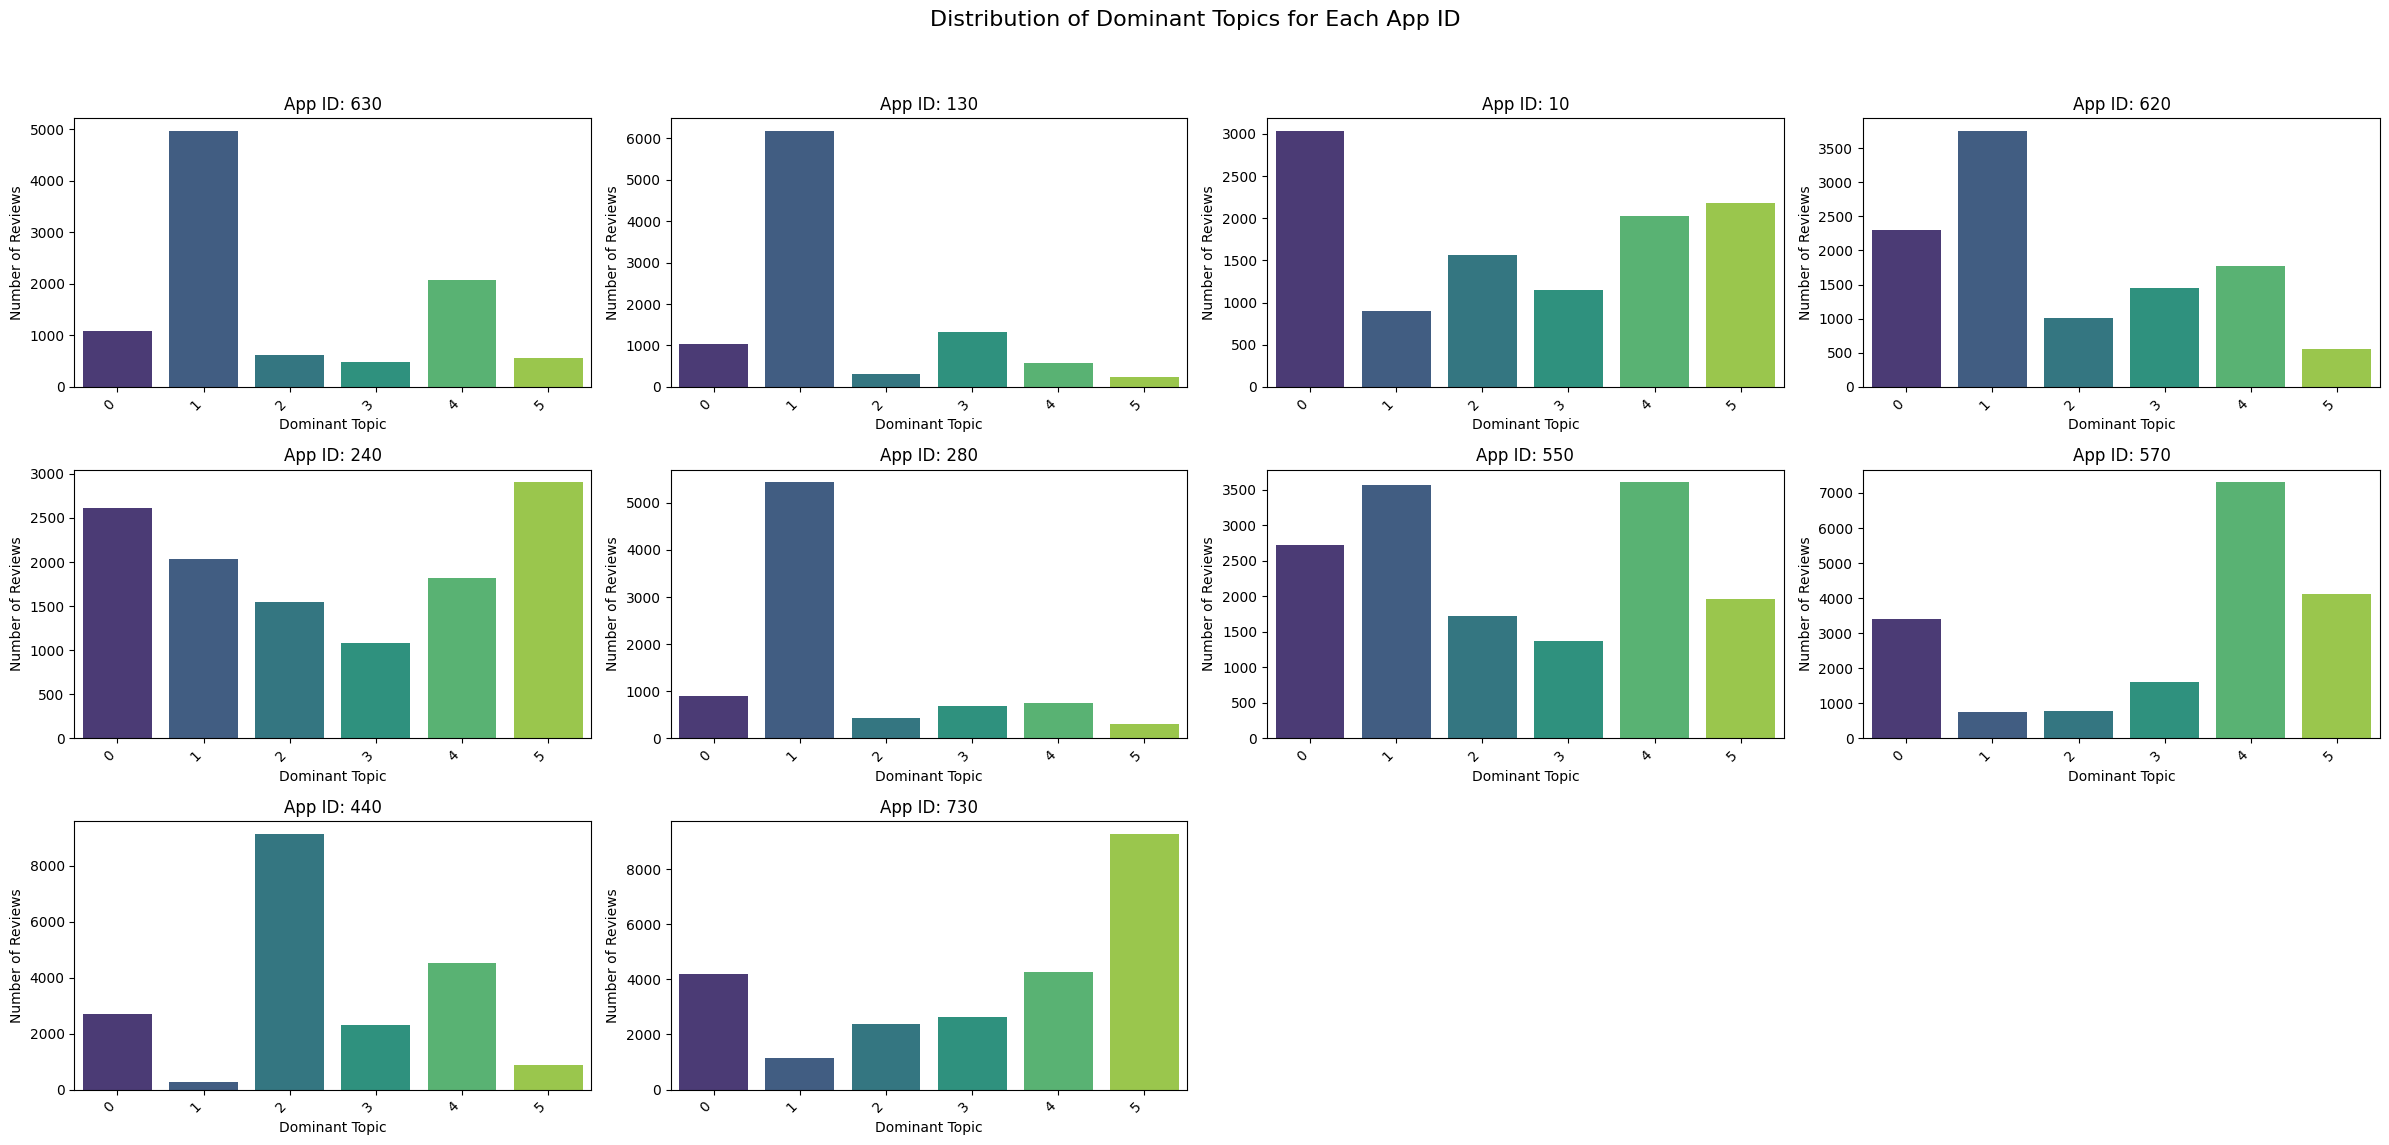

In [ ]:
unique_app_ids = df_top_10['app_id'].unique()

# Determine grid size for the plots
num_apps = len(unique_app_ids)
rows = 3
cols = 4

plt.figure(figsize=(cols * 6, rows * 4))

for i, app_id_val in enumerate(unique_app_ids):
    plt.subplot(rows, cols, i + 1)
    # Filter data for the current app_id
    df_filtered = df_top_10[df_top_10['app_id'] == app_id_val]

    # Count the occurrences of each dominant_topic
    topic_counts = df_filtered['dominant_topic'].value_counts().sort_index()

    # Create the bar plot
    sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis')
    plt.title(f'App ID: {app_id_val}')
    plt.xlabel('Dominant Topic')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Distribution of Dominant Topics for Each App ID', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping titles
plt.show()

After plotting the distribution of topics for each app id, the most interesting thing we can see is that the 2 half life games (130 and 280) have a very similar distribution of review topics. The 3 counter strike games (10, 240, and 730) are not nearly as similar in structure.

While we hoped to categorize specific games with topic modeling, we found that the topic modeling shown did a better job of categorizing types of games (e.g. team games, counter strike games) and categorizing types of reviews (spam, templated reviews, urls/links).